# Cookie Cats A/B Test: Does Moving the First Gate Improve Retention?

This notebook analyzes the impact of moving the first progression gate in the
Cookie Cats mobile game from level 30 to level 40.

The experiment groups are:

- **Control:** `gate_30`
- **Treatment:** `gate_40`

The main metrics are:

- 1-day retention
- 7-day retention
- Number of game rounds played within the first 14 days

**Dataset:** [Mobile Games A/B Testing — Cookie Cats](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)


## 1. Setup and Data Loading

### 1.1 Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### 1.2 Load the Dataset

The loading cell supports both Kaggle and the local project structure.


In [2]:
from pathlib import Path

kaggle_path = Path(
    "//kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv"
)
local_path = Path("data/cookie_cats.csv")
data_path = kaggle_path if kaggle_path.exists() else local_path

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Data source:", data_path)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Dataset loaded successfully.
Data source: //kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv
Number of rows: 90189
Number of columns: 5


In [3]:
display(df.head())

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


## 2. Data Quality Checks

Before starting the analysis, we check for missing values, duplicate records,
duplicate user IDs, and unexpected values in the experiment variables.


### 2.1 Missing Values and Duplicate Records


In [5]:
print("Missing values by column:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate user IDs:", df["userid"].duplicated().sum())
print("Unique users:", df["userid"].nunique())

Missing values by column:


userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate rows: 0
Duplicate user IDs: 0
Unique users: 90189


### 2.2 Validate Variable Values


In [6]:
print("Experiment groups:")
display(df["version"].value_counts())

print("1-day retention values:")
display(df["retention_1"].value_counts())

print("7-day retention values:")
display(df["retention_7"].value_counts())

print("Negative game-round values:",
      (df["sum_gamerounds"] < 0).sum())

Experiment groups:


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

1-day retention values:


retention_1
False    50036
True     40153
Name: count, dtype: int64

7-day retention values:


retention_7
False    73408
True     16781
Name: count, dtype: int64

Negative game-round values: 0


### 2.3 Experiment Group Distribution


In [7]:
group_distribution = pd.DataFrame({
    "user_count": df["version"].value_counts(),
    "percentage": df["version"].value_counts(normalize=True) * 100
})

group_distribution["percentage"] = (
    group_distribution["percentage"].round(2)
)

display(group_distribution)

,user_count,percentage
version,,
gate_40,45489,50.44
gate_30,44700,49.56


`gate_30` is defined as the control group and `gate_40` as the treatment group.
The number of users in the two groups is very similar, so there is no obvious
imbalance in group sizes.


## 3. Gameplay Distribution and Outlier Analysis

This section examines the central tendency and distribution of the number of
game rounds played, together with potential extreme values.


In [8]:
game_rounds_summary = df["sum_gamerounds"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

display(game_rounds_summary)

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
50%         16.000000
75%         51.000000
90%        134.000000
95%        221.000000
99%        493.000000
99.9%     1073.624000
max      49854.000000
Name: sum_gamerounds, dtype: float64

### 3.1 Players with the Highest Number of Game Rounds


In [9]:
top_players = df.nlargest(10, "sum_gamerounds")

display(top_players)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


### 3.2 Summary by Experiment Group


In [10]:
rounds_by_group = (
    df.groupby("version")["sum_gamerounds"]
    .agg(
        user_count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

display(rounds_by_group)

,user_count,mean,median,std,minimum,maximum
version,,,,,,
gate_30,44700,52.46,17.0,256.72,0,49854
gate_40,45489,51.30,16.0,103.29,0,2640


### 3.3 Visualize the Distribution


In [11]:
plot_limit = df["sum_gamerounds"].quantile(0.99)
df_plot = df[df["sum_gamerounds"] <= plot_limit]

print("Plot upper limit:", plot_limit)
print("Observations included in the plot:", len(df_plot))

Plot upper limit: 493.0
Observations included in the plot: 89291


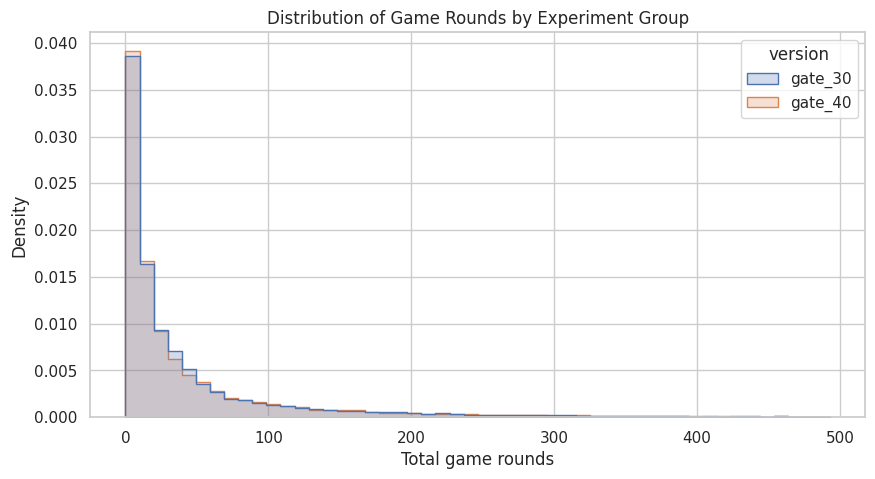

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_plot,
    x="sum_gamerounds",
    hue="version",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Distribution of Game Rounds by Experiment Group")
plt.xlabel("Total game rounds")
plt.ylabel("Density")
plt.show()

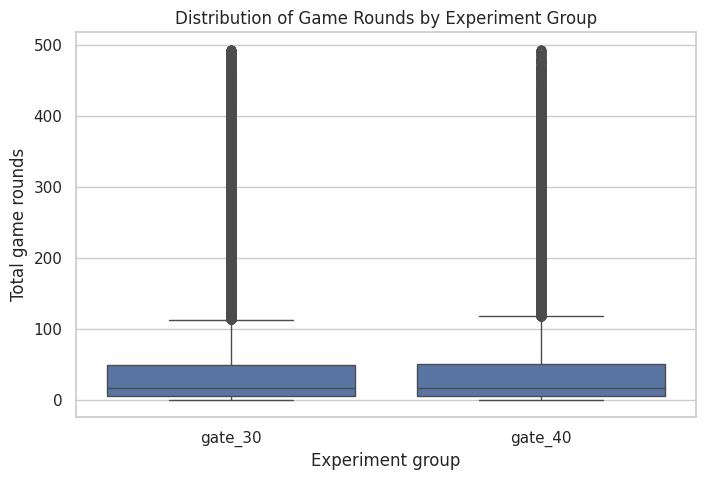

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="version",
    y="sum_gamerounds"
)

plt.title("Distribution of Game Rounds by Experiment Group")
plt.xlabel("Experiment group")
plt.ylabel("Total game rounds")
plt.show()

The distribution is right-skewed: most players completed relatively few rounds,
while a small group played a very high number of rounds. As a result, the mean
is sensitive to high values. The similar group medians suggest that typical
player behavior may be comparable between the two groups.

For readability, the plots are limited to the 99th percentile. No observations
have been removed from the main dataset at this stage.


### 3.4 Extreme-Value Sensitivity Analysis


In [14]:
extreme_index = df["sum_gamerounds"].idxmax()
extreme_player = df.loc[[extreme_index]]

display(extreme_player)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [15]:
df_without_extreme = df.drop(index=extreme_index)

summary_with_extreme = (
    df.groupby("version")["sum_gamerounds"]
    .agg(mean="mean", median="median", std="std")
)

summary_without_extreme = (
    df_without_extreme.groupby("version")["sum_gamerounds"]
    .agg(mean="mean", median="median", std="std")
)

sensitivity_comparison = pd.concat(
    {
        "All data": summary_with_extreme,
        "Excluding extreme value": summary_without_extreme
    },
    names=["scenario", "version"]
).round(2)

display(sensitivity_comparison)

mean  median     std
scenario                version                       
All data                gate_30  52.46    17.0  256.72
                        gate_40  51.30    16.0  103.29
Excluding extreme value gate_30  51.34    17.0  102.06
                        gate_40  51.30    16.0  103.29

## 4. Retention Analysis

Because the retention columns are Boolean, their group means directly represent
retention rates.


In [16]:
retention_rates = (
    df.groupby("version")[["retention_1", "retention_7"]]
    .mean()
)

retention_rates_percent = (retention_rates * 100).round(2)

display(retention_rates_percent)

,retention_1,retention_7
version,,
gate_30,44.82,19.02
gate_40,44.23,18.20


### 4.1 Absolute and Relative Uplift


- **Absolute uplift:** The percentage-point difference between the two rates.
- **Relative uplift:** The percentage change relative to the control rate.

The effects are calculated as:

```text
absolute_uplift_pp = treatment_rate - control_rate
relative_uplift_% = (treatment_rate - control_rate) / control_rate
```


In [17]:
control_rates = retention_rates.loc["gate_30"]
treatment_rates = retention_rates.loc["gate_40"]

uplift_summary = pd.DataFrame({
    "control_rate_%": control_rates * 100,
    "treatment_rate_%": treatment_rates * 100,
    "absolute_uplift_pp": (
        treatment_rates - control_rates
    ) * 100,
    "relative_uplift_%": (
        (treatment_rates - control_rates) / control_rates
    ) * 100
}).round(2)

display(uplift_summary)

,control_rate_%,treatment_rate_%,absolute_uplift_pp,relative_uplift_%
retention_1,44.82,44.23,-0.59,-1.32
retention_7,19.02,18.20,-0.82,-4.31


## 5. Hypothesis Testing


### 5.1 Hypotheses

For each retention metric:

**H₀ (Null hypothesis):** There is no difference between the retention rates of
the `gate_30` and `gate_40` groups.

**H₁ (Alternative hypothesis):** There is a difference between the retention
rates of the `gate_30` and `gate_40` groups.

The significance level is set to $\alpha = 0.05$.


### 5.2 Two-Proportion Z-Test


A two-proportion z-test is appropriate because the retention variables are
binary and both experiment groups have large sample sizes. A two-sided test is
used to avoid choosing the direction after observing the results.


In [18]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05

control = df[df["version"] == "gate_30"]
treatment = df[df["version"] == "gate_40"]

test_results = []

for metric in ["retention_1", "retention_7"]:
    control_success = control[metric].sum()
    treatment_success = treatment[metric].sum()

    z_stat, p_value = proportions_ztest(
        count=[treatment_success, control_success],
        nobs=[len(treatment), len(control)],
        alternative="two-sided"
    )

    test_results.append({
        "metric": metric,
        "z_statistic": z_stat,
        "p_value": p_value,
        "decision": (
            "Reject H0"
            if p_value < alpha
            else "Fail to reject H0"
        )
    })

z_test_results = pd.DataFrame(test_results).set_index("metric")
display(z_test_results.round(4))

,z_statistic,p_value,decision
metric,,,
retention_1,-1.7841,0.0744,Fail to reject H0
retention_7,-3.1644,0.0016,Reject H0


### 5.3 Z-Test Results

For 1-day retention, the p-value is 0.0744. Since this is greater than 0.05,
there is insufficient evidence to conclude that the control and treatment
groups have different 1-day retention rates.

For 7-day retention, the p-value is 0.0016. Since this is less than 0.05, the
difference is statistically significant. The observed effect is unfavorable to
the treatment group: moving the gate to level 40 reduced 7-day retention.


### 5.4 Confidence Intervals for the Differences


In [19]:
from scipy.stats import norm

z_critical = norm.ppf(0.975)
confidence_results = []

for metric in ["retention_1", "retention_7"]:
    control_rate = control[metric].mean()
    treatment_rate = treatment[metric].mean()

    difference = treatment_rate - control_rate

    standard_error = np.sqrt(
        treatment_rate * (1 - treatment_rate) / len(treatment)
        + control_rate * (1 - control_rate) / len(control)
    )

    ci_lower = difference - z_critical * standard_error
    ci_upper = difference + z_critical * standard_error

    confidence_results.append({
        "metric": metric,
        "difference_pp": difference * 100,
        "ci_lower_pp": ci_lower * 100,
        "ci_upper_pp": ci_upper * 100
    })

confidence_intervals = (
    pd.DataFrame(confidence_results)
    .set_index("metric")
    .round(2)
)

display(confidence_intervals)

,difference_pp,ci_lower_pp,ci_upper_pp
metric,,,
retention_1,-0.59,-1.24,0.06
retention_7,-0.82,-1.33,-0.31


### 5.5 Interpreting the Confidence Intervals

The 95% confidence interval for the 1-day retention difference is
[-1.24, 0.06] percentage points. Because the interval includes zero, the
direction of the effect remains uncertain.

The 95% confidence interval for the 7-day retention difference is
[-1.33, -0.31] percentage points. Because the entire interval is negative, the
result supports a negative effect from moving the gate to level 40.


## 6. Bootstrap Validation


Bootstrap resampling estimates the possible distribution of the retention
difference by repeatedly generating samples based on the observed data.

Because the retention variables are binary, binomial sampling provides an
efficient equivalent to resampling the empirical Boolean observations.


In [20]:
rng = np.random.default_rng(42)
n_bootstrap = 10_000

bootstrap_results = []
bootstrap_differences = {}

for metric in ["retention_1", "retention_7"]:
    control_rate = control[metric].mean()
    treatment_rate = treatment[metric].mean()

    boot_control = (
        rng.binomial(
            n=len(control),
            p=control_rate,
            size=n_bootstrap
        ) / len(control)
    )

    boot_treatment = (
        rng.binomial(
            n=len(treatment),
            p=treatment_rate,
            size=n_bootstrap
        ) / len(treatment)
    )

    boot_difference = boot_treatment - boot_control
    bootstrap_differences[metric] = boot_difference * 100

    ci_lower, ci_upper = np.percentile(
        boot_difference,
        [2.5, 97.5]
    )

    bootstrap_results.append({
        "metric": metric,
        "observed_difference_pp": (
            treatment_rate - control_rate
        ) * 100,
        "bootstrap_ci_lower_pp": ci_lower * 100,
        "bootstrap_ci_upper_pp": ci_upper * 100,
        "bootstrap_samples_above_zero_%": (
            boot_difference > 0
        ).mean() * 100
    })

bootstrap_summary = (
    pd.DataFrame(bootstrap_results)
    .set_index("metric")
    .round(2)
)

display(bootstrap_summary)

,observed_difference_pp,bootstrap_ci_lower_pp,bootstrap_ci_upper_pp,bootstrap_samples_above_zero_%
metric,,,,
retention_1,-0.59,-1.25,0.06,3.47
retention_7,-0.82,-1.32,-0.31,0.10


### 6.1 Visualize the Bootstrap Distributions


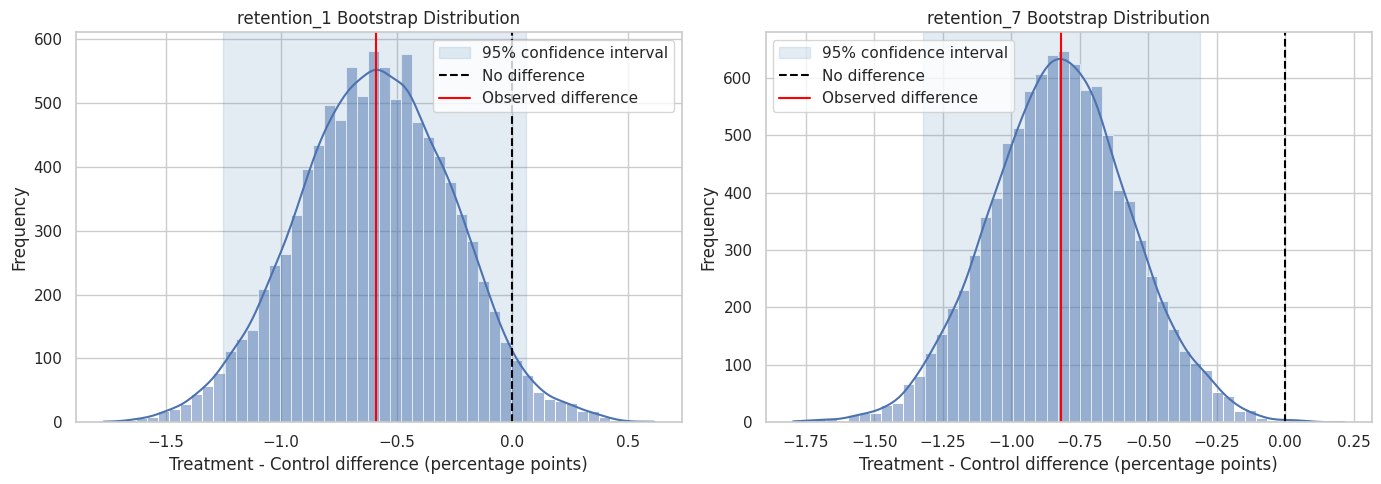

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(
    axes,
    ["retention_1", "retention_7"]
):
    differences = bootstrap_differences[metric]

    observed_difference = bootstrap_summary.loc[
        metric, "observed_difference_pp"
    ]

    ci_lower = bootstrap_summary.loc[
        metric, "bootstrap_ci_lower_pp"
    ]

    ci_upper = bootstrap_summary.loc[
        metric, "bootstrap_ci_upper_pp"
    ]

    sns.histplot(
        differences,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvspan(
        ci_lower,
        ci_upper,
        color="steelblue",
        alpha=0.15,
        label="95% confidence interval"
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        label="No difference"
    )

    ax.axvline(
        observed_difference,
        color="red",
        linestyle="-",
        label="Observed difference"
    )

    ax.set_title(f"{metric} Bootstrap Distribution")
    ax.set_xlabel("Treatment - Control difference (percentage points)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Conclusion and Product Recommendation

This A/B test examined how moving the first progression gate in Cookie Cats
from level 30 to level 40 affected player behavior.

### Gameplay Findings

The game-round distribution is strongly right-skewed. A single observation of
49,854 rounds in the `gate_30` group substantially affects the group mean.

After excluding this observation in the sensitivity analysis, the mean numbers
of game rounds are:

- `gate_30`: 51.34
- `gate_40`: 51.30

Therefore, there is no evidence that moving the gate to level 40 produced a
meaningful improvement in gameplay activity.

### 1-Day Retention

- Control rate: 44.82%
- Treatment rate: 44.23%
- Absolute uplift: -0.59 percentage points
- Relative uplift: -1.32%
- P-value: 0.0744
- 95% confidence interval: [-1.24, 0.06] percentage points

The treatment group has lower observed 1-day retention. However, the p-value is
greater than 0.05 and the confidence interval includes zero, so the difference
is not statistically significant.

### 7-Day Retention

- Control rate: 19.02%
- Treatment rate: 18.20%
- Absolute uplift: -0.82 percentage points
- Relative uplift: -4.31%
- P-value: 0.0016
- 95% confidence interval: [-1.33, -0.31] percentage points

The treatment group has statistically significantly lower 7-day retention. The
bootstrap analysis also shows that this negative result is stable across
resamples.

### Product Recommendation

Moving the gate from level 30 to level 40 is not recommended. The `gate_40`
version provides no meaningful improvement in game rounds while producing a
statistically significant decline in 7-day retention.

Based on the available evidence, the gate should remain at level 30.

This recommendation is limited to the available retention and game-round
metrics. Revenue, in-app purchases, and user segments are not included in the
dataset, so potential effects in those areas would require additional analysis.
